## Packages and Libraries

In [1]:
# import pandas as pd
import numpy as np
import os
import idx2numpy
import matplotlib.pyplot as plt
import gradio as gr
from torchvision import transforms
from PIL import Image
from pyngrok import ngrok
from flask import Flask

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms

## Loadind Data 

In [3]:
dataset_path = '/Users/user/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1'

train_images_path = os.path.join(dataset_path, 'train-images.idx3-ubyte')
train_labels_path = os.path.join(dataset_path, 'train-labels.idx1-ubyte')

train_images = idx2numpy.convert_from_file(train_images_path)
train_labels = idx2numpy.convert_from_file(train_labels_path)

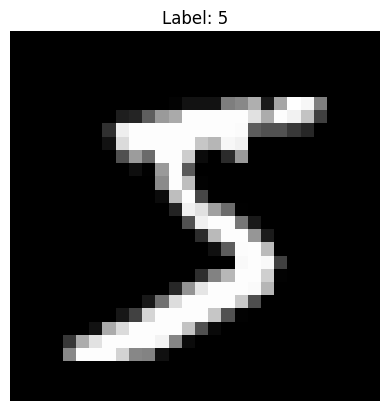

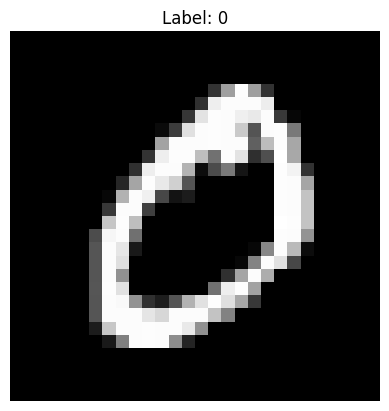

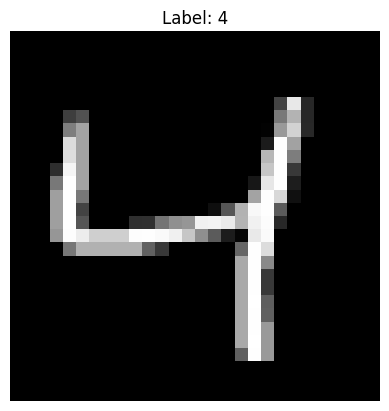

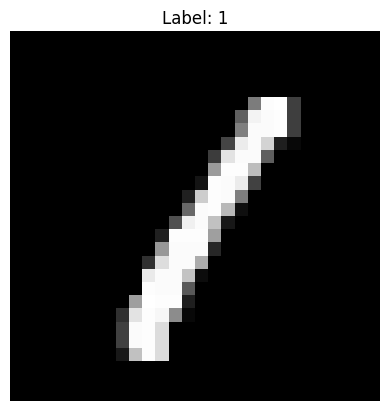

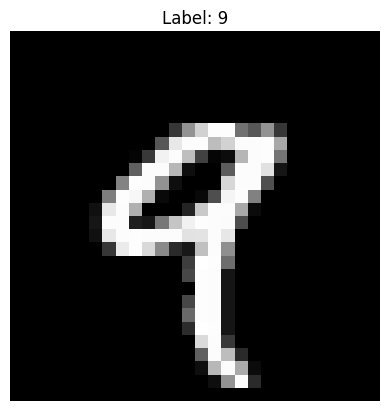

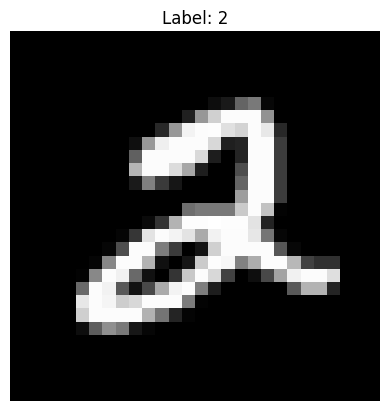

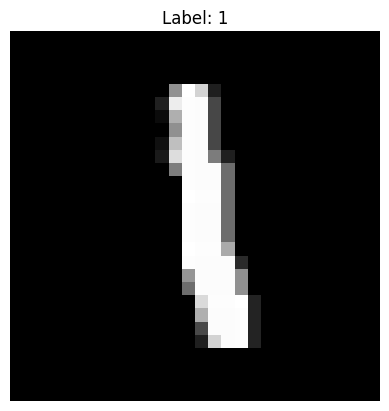

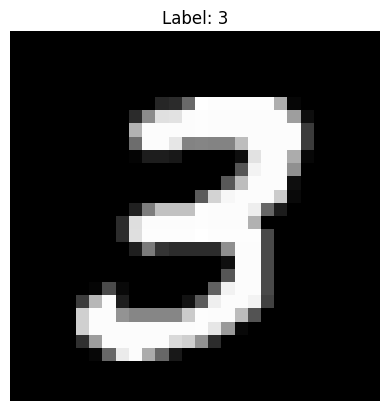

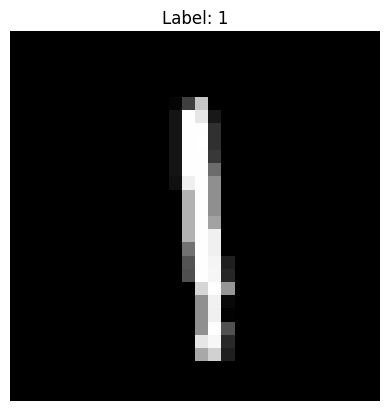

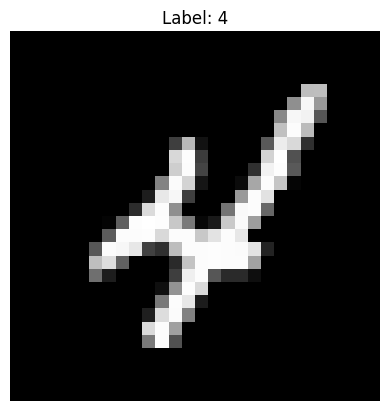

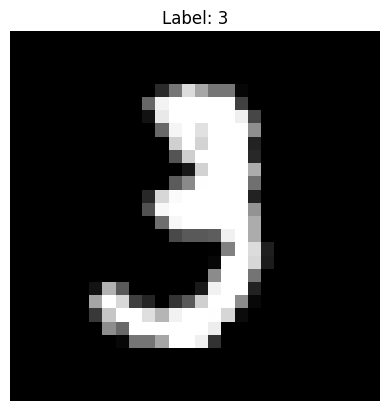

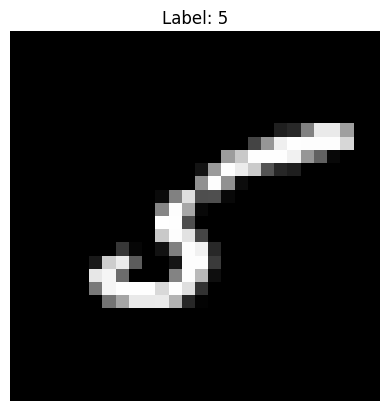

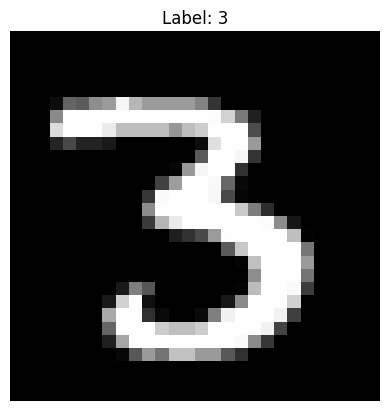

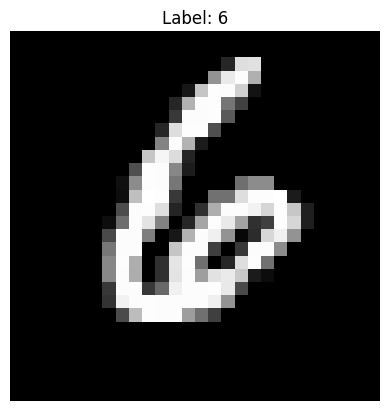

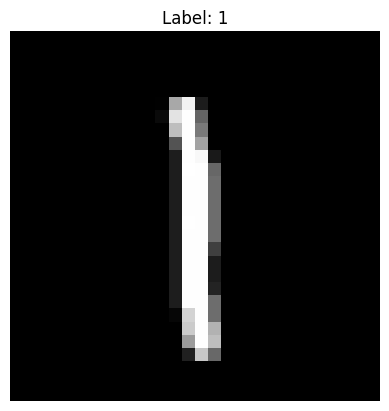

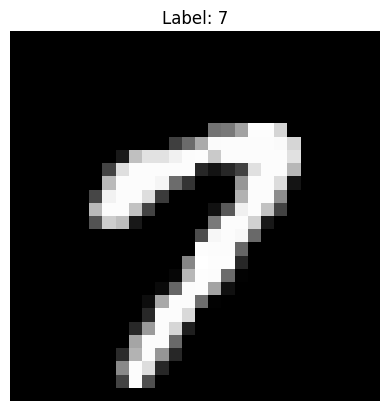

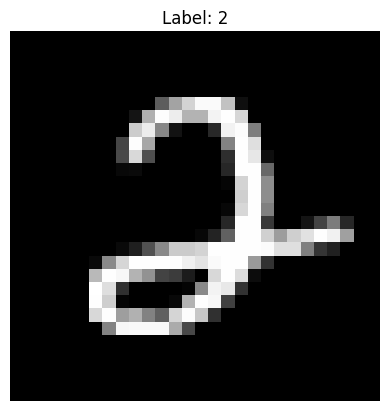

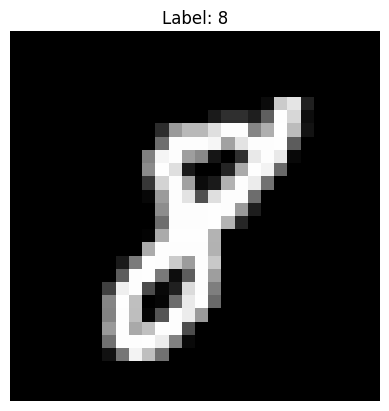

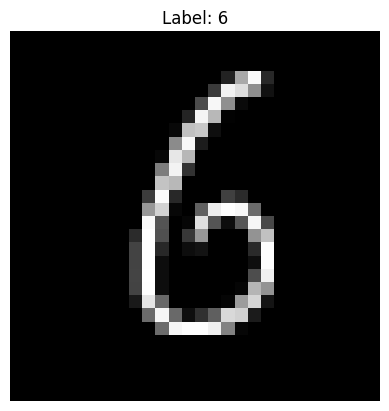

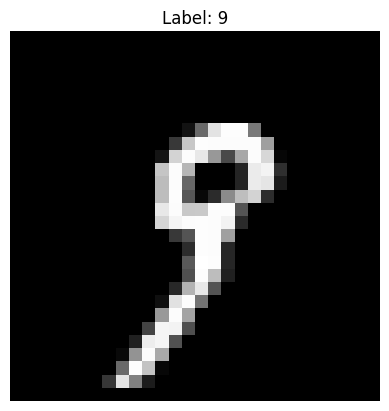

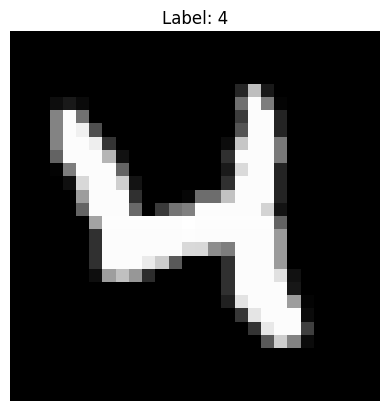

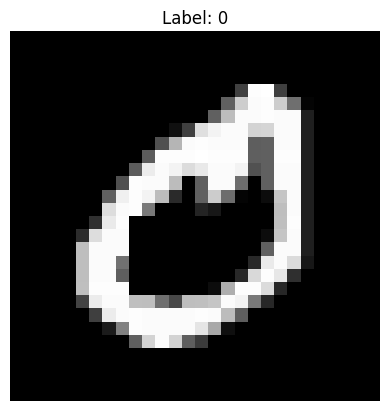

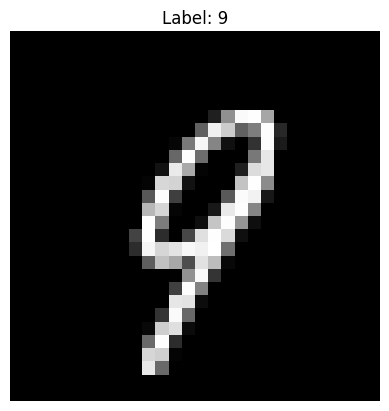

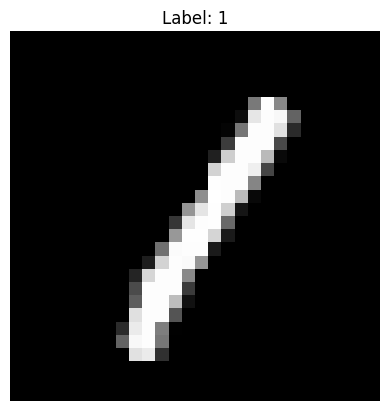

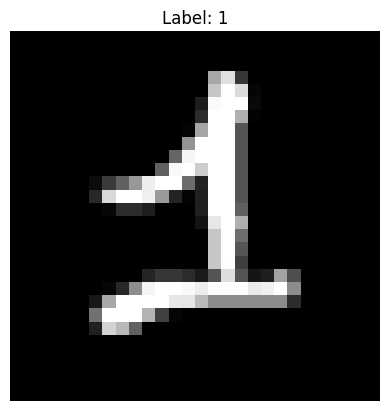

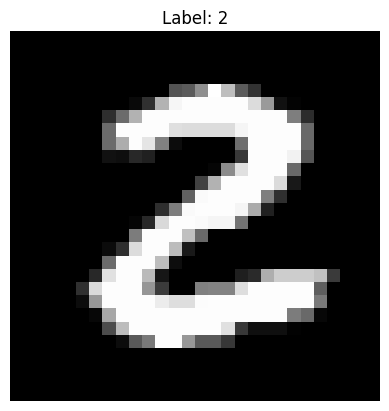

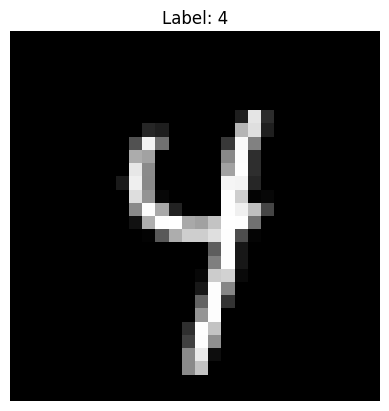

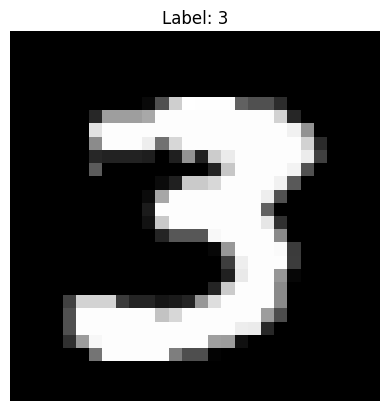

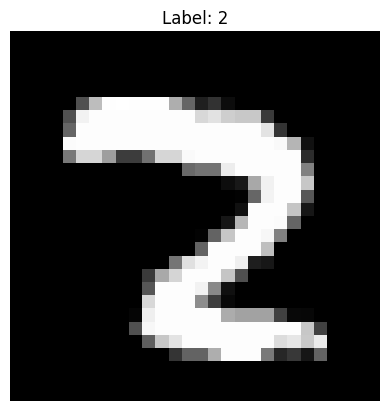

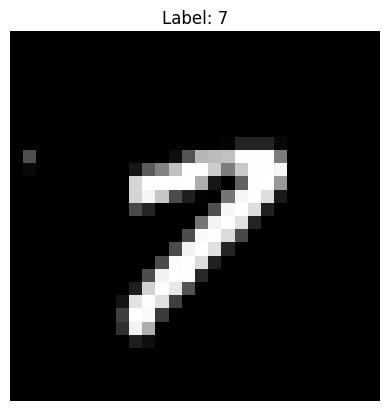

In [7]:
X_train = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1) / 255.0 
y_train = torch.tensor(train_labels, dtype=torch.long)


train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
for i in range(30):
    image = X_train[i].squeeze(0) 
    label = y_train[i].item()

    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

## NN model buidling

In [8]:


class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(-1, 64 * 7 * 7)  
        x = F.relu(self.fc1(x))  
        x = self.fc2(x)
        return x


In [9]:
model = DigitCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct_preds += (predicted == labels).sum().item()
        total_preds += labels.size(0)
        
        running_loss += loss.item()
    
    accuracy = (correct_preds / total_preds) * 100  # Calculate accuracy
    print(f"Epoch {epoch+1} - Loss: {running_loss/len(train_loader):.4f} - Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), 'digit_cnn.pth')




Epoch 1 - Loss: 0.1739 - Accuracy: 94.74%
Epoch 2 - Loss: 0.0495 - Accuracy: 98.51%
Epoch 3 - Loss: 0.0344 - Accuracy: 98.93%
Epoch 4 - Loss: 0.0265 - Accuracy: 99.19%
Epoch 5 - Loss: 0.0194 - Accuracy: 99.40%


In [10]:

if os.path.exists('digit_cnn.pth'):
    model.load_state_dict(torch.load('digit_cnn.pth'))
else:
    print("Error: Model file not found.")

model.eval()


correct_preds = 0
total_preds = 0

with torch.no_grad(): 
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct_preds += (predicted == labels).sum().item()
        total_preds += labels.size(0)

test_accuracy = (correct_preds / total_preds) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.21%


In [11]:
torch.save(model.state_dict(), 'digit_cnn_new.pth')
if os.path.exists('digit_cnn_new.pth'):
    model.load_state_dict(torch.load('digit_cnn_new.pth'))
else:
    print("Error: Model file not found.")


In [12]:
model.load_state_dict(torch.load('digit_cnn_new.pth'))
model.eval()

DigitCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)